# Volume change on shelf over time, panant

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [13]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-daily-pan01_test_01-986f8f63/output000/*ocean_daily_z_*.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-daily-expt-2f759912/output000/*ocean_daily_z_*.nc'))

In [24]:
# Time variant variables
def preprocess(ds):
    ds = ds[['volcello','so']].sel(yh=lat_slice)
    return ds

data_C = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
data_M = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')

In [25]:
data_C

<xarray.Dataset> Size: 3GB
Dimensions:   (time: 3, z_l: 75, yh: 460, xh: 3600)
Coordinates:
  * time      (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
  * z_l       (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yh        (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh        (xh) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Data variables:
    volcello  (time, z_l, yh, xh) float32 1GB dask.array<chunksize=(1, 33, 313, 1545), meta=np.ndarray>
    so        (time, z_l, yh, xh) float32 1GB dask.array<chunksize=(1, 33, 313, 1545), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             panan
    associated_files:  areacello: 20010101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [26]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [27]:
depth = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask = (0 * depth).fillna(1)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom6_01')

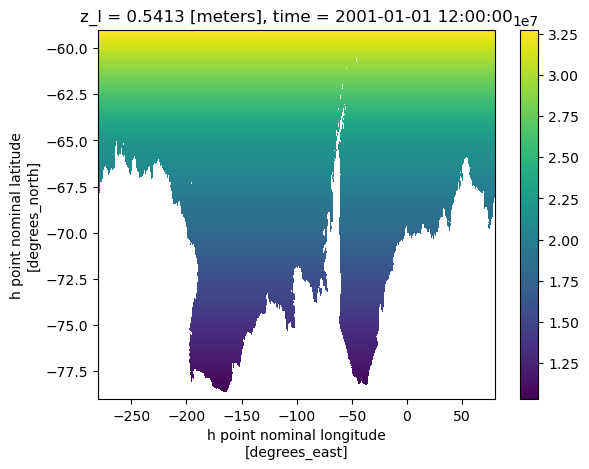

In [28]:
# Doing spatial average
area = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['areacello']
var = data_C.so.isel(time=0).isel(z_l=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [31]:
# Salinity variable
vol_C = data_C['volcello'].where(shelf_mask == 1)
vol_M = data_M['volcello'].where(shelf_mask == 1)

In [32]:
# Spatial average
shelf_area = area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

vol_C_time = (area_corr * vol_C).sum(['xh', 'yh']) / shelf_area
vol_M_time = (area_corr * vol_M).sum(['xh', 'yh']) / shelf_area

In [33]:
vol_C_time

<xarray.DataArray (time: 3, z_l: 75)> Size: 900B
dask.array<truediv, shape=(3, 75), dtype=float32, chunksize=(1, 33), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
  * z_l      (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Control experiment
vol_C_time.plot(ax=axs[0], y='z_l', cmap='viridis')
axs[0].set_ylabel('Depth (m)')
axs[0].set_ylim(0,1000)
axs[0].set_title('Control Experiment Volume Change')

# Meltwater experiment
vol_M_time.plot(ax=axs[1], y='z_l', cmap='viridis')
axs[1].set_ylabel('Depth (m)')
axs[1].set_ylim(0,1000)
axs[1].set_title('Meltwater Experiment Volume Change')

axs[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

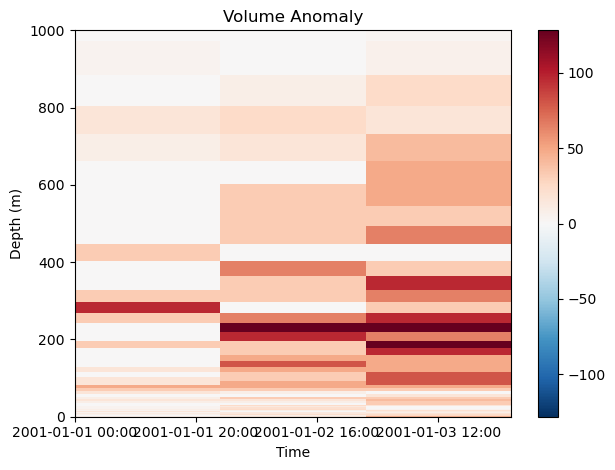

In [47]:
# Anomaly
vol_anom_time = vol_M_time - vol_C_time

vol_anom_time.plot(y='z_l', cmap='RdBu_r')
plt.ylabel('Depth (m)')
plt.ylim(0,1000)
plt.title('Volume Anomaly')
plt.xlabel('Time')

plt.tight_layout()
plt.show()

Okay so we see that volume is changing, mostly around 300m depth. Is there a better way to present this information? This plot is a bit rough.

In [48]:
vol_C_column = vol_C_time.sum('z_l')
vol_M_column = vol_M_time.sum('z_l')

I don't think I need to thickness-weight this because volcello should already account for that?

In [49]:
vol_anom_column = vol_M_column - vol_C_column

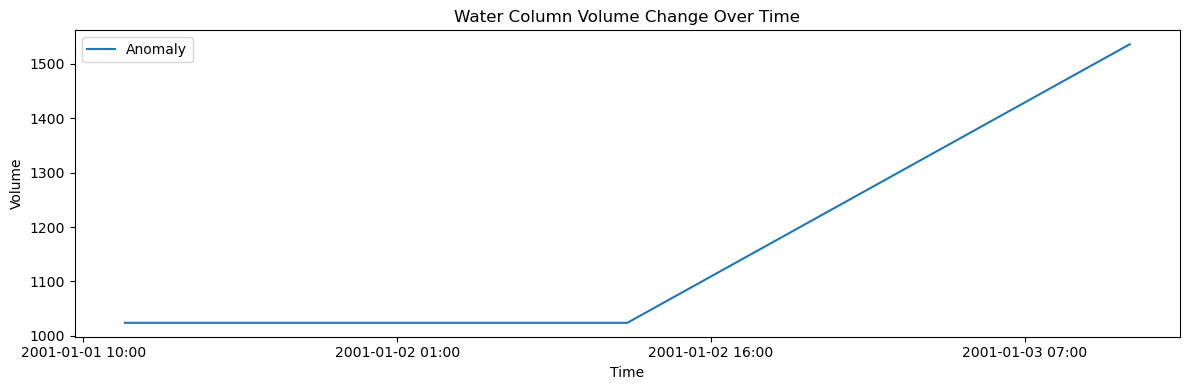

In [50]:
plt.figure(figsize=(12, 4))

# vol_C_column.plot(label='Control')
# vol_M_column.plot(label='Meltwater')
vol_anom_column.plot(label='Anomaly')

plt.legend()
plt.ylabel('Volume')
plt.xlabel('Time')
plt.title('Water Column Volume Change Over Time')
plt.tight_layout()
plt.show()